# PDAN8411_POE
# Part 1 — Linear Regression
# Tumisi Mosoeu
# ST10356048

## 1. Evaluating the dataset for suitability for Linear Regression

The dataset is suitable for Linear Regression because **charges** is a continuous numeric variable, which makes it appropriate for predicting a numeric outcome. The other variables in the dataset are also relevant to medical costs, although the categorical variables will need to be encoded before modelling. The dataset must still be checked for quality issues and explored properly before training the model.

## 2. Planned analysis approach

I will first explore and clean the dataset using EDA, including checks for missing values, duplicates, distributions, and relationships between variables. After that, I will prepare and encode the features, train a Linear Regression model, and evaluate it using MAE, MSE, RMSE, R², and residual analysis. I will retrain if needed. The report will then summarise the main steps, findings, and results.

## 3. Conduct your analysis

### (a) Exploratory Data Analysis (EDA)

In this section, I explore the medical insurance dataset before training the Linear Regression model. The aim is to understand the data properly, check its quality, and identify any patterns that may affect the model later.

- I checked the dataset structure, including the number of rows and columns, the column names, and the data types.
- I checked for missing values to make sure the dataset was complete.
- I checked for duplicate rows and removed the one duplicate that was found.
- I used summary statistics to get a quick overview of the numeric variables.
- I created histograms to see how the numeric variables are distributed.
- I used boxplots to look for unusual values that may affect the model.
- I used a pair plot and scatterplots to explore relationships between the numeric variables and **charges**.
- I created a correlation heatmap to see which numeric variables appear more strongly related to **charges**.
- I compared **charges** across categorical variables such as **sex, smoker, region,** and **children** to see whether they may be useful after encoding.

**Take note:** This step helps me understand the dataset better and guides the next stages of the analysis, especially feature preparation, model training, and evaluation.

#### Import libraries and load the dataset


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset loaded correctly, and the first five rows show the main variables that will be used in the analysis which match the brief for this task.

#### Check the size of the dataset

In [34]:
df.shape

(1338, 7)

The dataset contains **1,338 rows** and **7 columns**. This means there are enough records to explore patterns in the data and build a Linear Regression model.

#### Check the column names and data types

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The output shows that all **1,338 records are non-null** in every column meaning there are no missing values at this stage. It also confirms that the dataset contains both **numeric variables**  and **categorical variables**. The numeric variables are already in a usable format but the categorical ones need to be encoded before model training.

#### Check for missing values

In [42]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

The result shows that there are **no missing values** in any of the columns.

#### Check for duplicate rows

In [45]:
df.duplicated().sum()

1

The dataset contains **1 duplicate row**. 

#### Remove duplicate rows

In [78]:
df = df.drop_duplicates()
df.duplicated().sum(), df.shape

(0, (1337, 7))

The duplicate row was removed successfully. There are now **0 duplicate rows**

#### Generate summary statistics

In [83]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


#### Creating a condensed summary statistics table

To make the results easier to present, I created a smaller summary table from the full `describe()` output. This condensed table keeps only the most useful values for the report, namely the mean, median, minimum, and maximum for each numeric variable.

In [122]:
summary_stats = df.describe().T[['mean', '50%', 'min', 'max']]
summary_stats = summary_stats.rename(columns={
    'mean': 'Mean',
    '50%': 'Median',
    'min': 'Minimum',
    'max': 'Maximum'
})
summary_stats = summary_stats.round(2)
summary_stats.index = ['Age', 'BMI', 'Children', 'Charges']

summary_stats.to_excel("summary_statistics.xlsx")
summary_stats

,Mean,Median,Minimum,Maximum
Age,39.22,39.00,18.00,64.00
BMI,30.66,30.40,15.96,53.13
Children,1.10,1.00,0.00,5.00
Charges,13279.12,9386.16,1121.87,63770.43


The summary statistics give a quick picture of the numeric variables in the dataset. The average age is about **39 years**, the average BMI is about **30.66**, and the average number of children is about **1.10**. **Charges** has a very wide range, from about **1,121.87** to **63,770.43**, which shows that the target variable is spread out quite a lot. The mean charge is also clearly higher than the median, which suggests that the data is **right-skewed**.

#### Plot histograms for the numeric variables

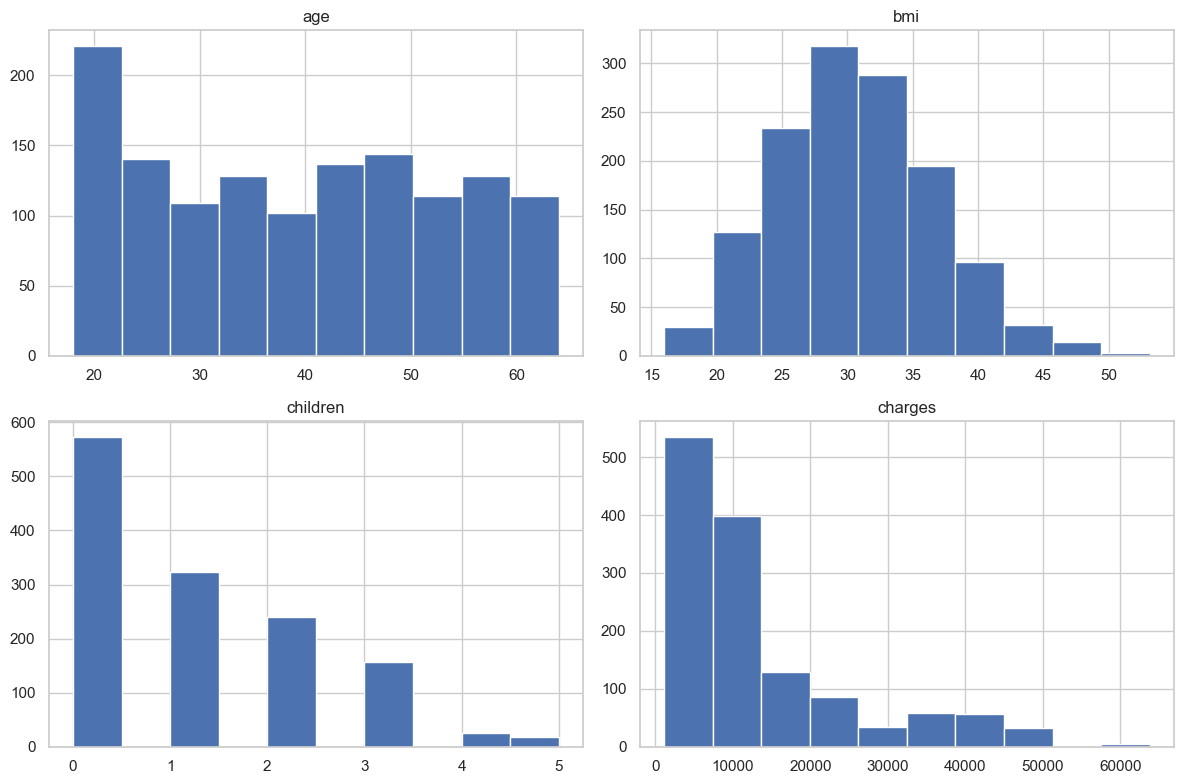

In [135]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

The histograms show that **age** is spread out fairly, **BMI** is mostly concentrated around the high 20s to low 30s. The **children** variable is concentrated at lower values, with most falling between **0 and 2**. The **charges** histogram is clearly **right-skewed**, which means most charges are lower, but a smaller number of very high charges pull the distribution to the right. This suggests that the target variable is not normally distributed and may contain some high-value cases.

#### Creating a histogram for charges

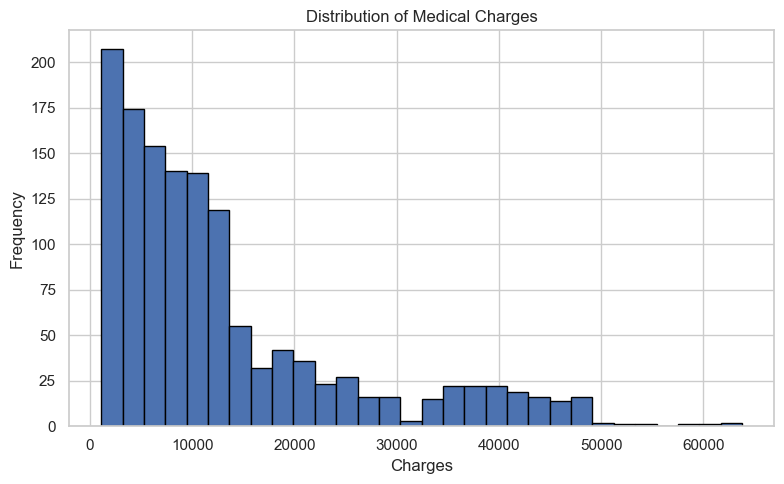

In [128]:
plt.figure(figsize=(8, 5))
plt.hist(df['charges'], bins=30, edgecolor='black')
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("histogram_charges.png", bbox_inches="tight")
plt.show()

For the report, I only want the histogram for **charges**, because it is the target variable and it tells the clearest part of the EDA story. I therefore created a cleaner version of it so that it can be inserted into the report more neatly.

#### Plot boxplots for the numeric variables

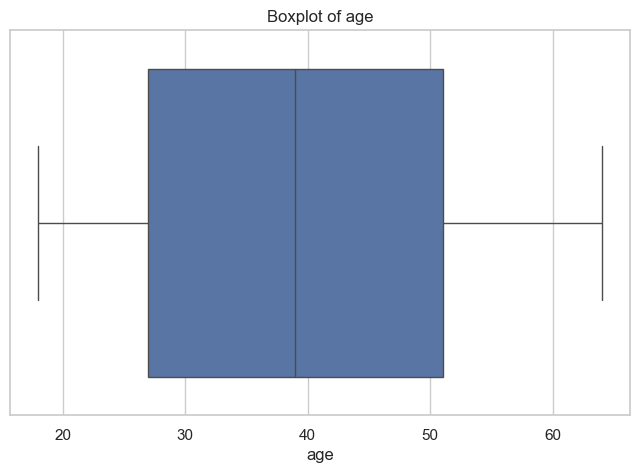

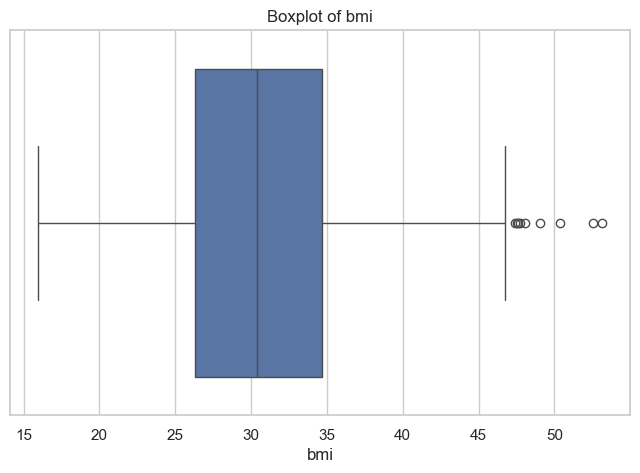

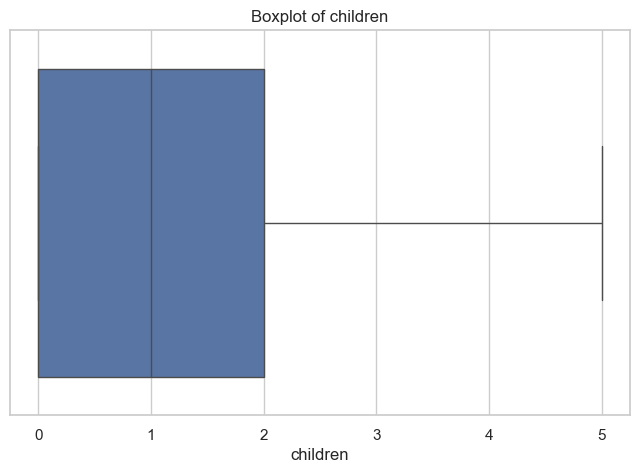

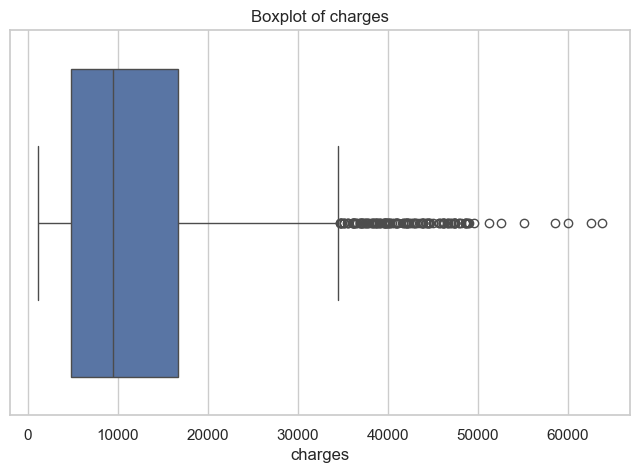

In [92]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

The boxplots show that **age** and **children** do not have strong outlier patterns. **BMI** has a few higher values above the upper whisker, which suggests some possible outliers. **Charges** stands out the most, with many high-value outliers. This supports the earlier histogram and summary statistics, which already suggested that charges is not evenly distributed.

#### Creating a boxplot for charges only

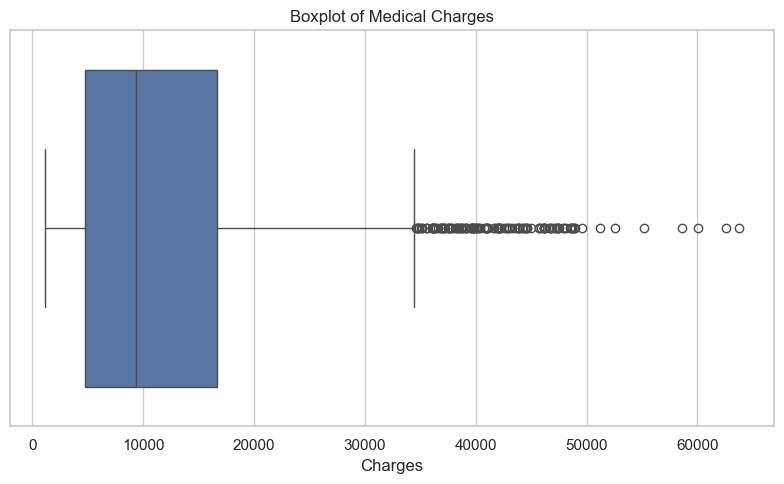

In [139]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Medical Charges")
plt.xlabel("Charges")
plt.tight_layout()
plt.savefig("boxplot_charges.png", bbox_inches="tight")
plt.show()

I used boxplots for all the numeric variables to check for unusual values across the dataset. For the report, I only need the boxplot for **charges** in the report, because it supports one of the main EDA findings more clearly. 

#### Create a pair plot

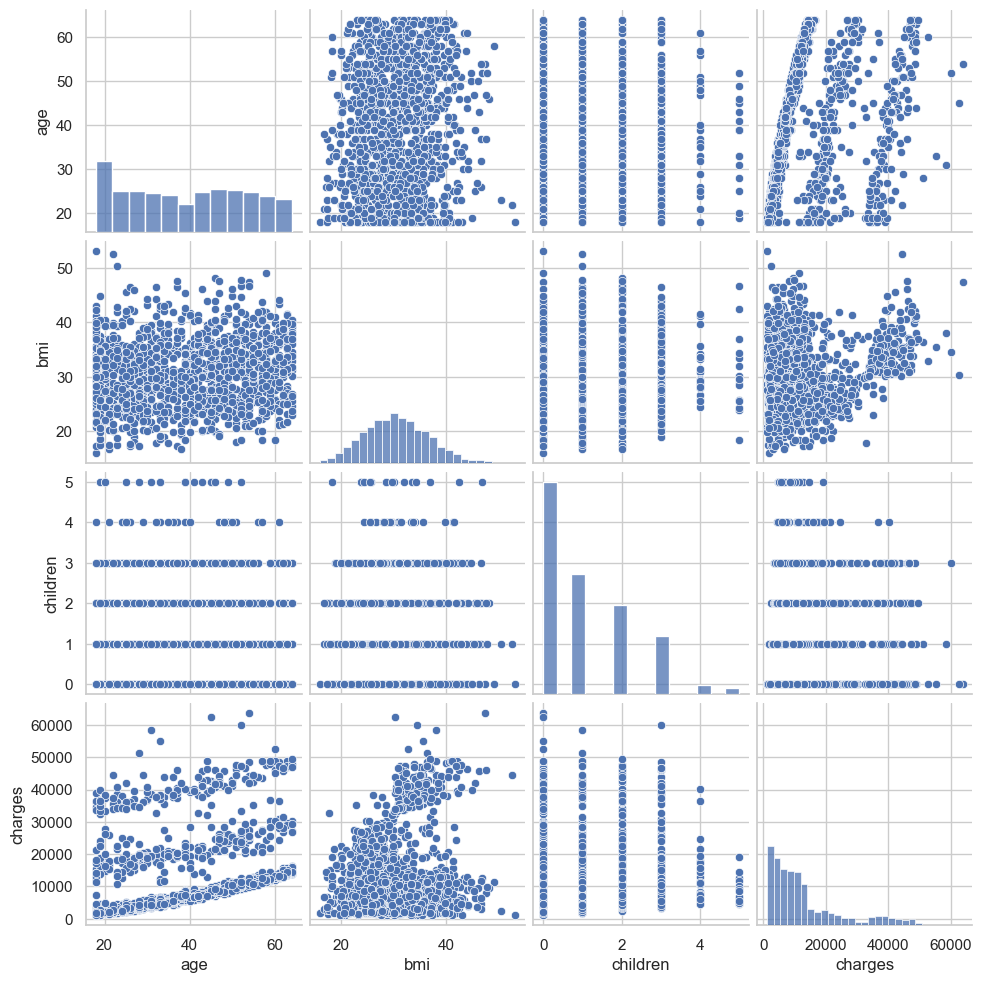

In [145]:
pair_plot = sns.pairplot(df[['age', 'bmi', 'children', 'charges']])
pair_plot.figure.savefig("pairplot_numeric_variables.png", bbox_inches="tight")
plt.show()

The pair plot gives a view of how the numeric variables relate to one another. It shows that **charges** tends to increase with **age**, while the relationship with **BMI** is less clear. The pattern between **children** and **charges** looks weak. It also confirms that **charges** is right-skewed and includes some much higher values than the rest of the data.

#### Create a correlation heatmap

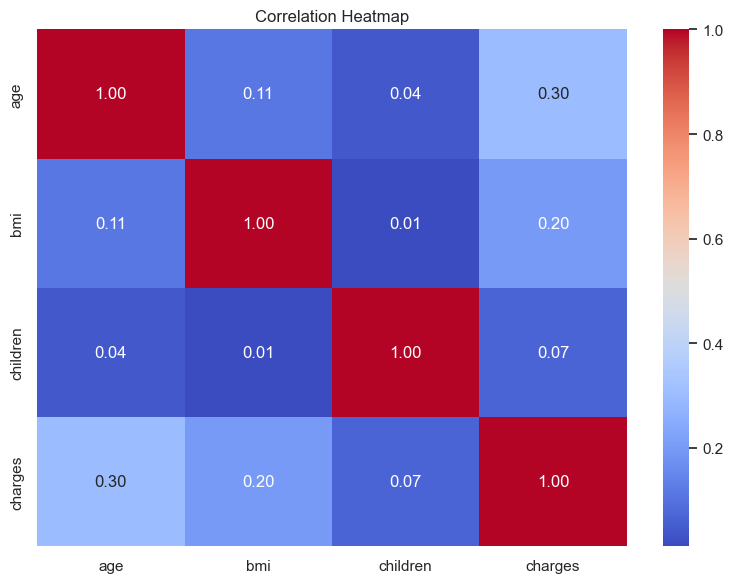

In [154]:
corr = df[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

The correlation heatmap shows that **age** has the strongest relationship with **charges** out of the numeric variables, followed by **BMI**. **Children** has a very weak relationship with **charges**. The heatmap also shows weak relationships between the predictors themselves, which suggests that there is no strong overlapping between these numeric features at this stage.

#### Explore how charges relate to other variables

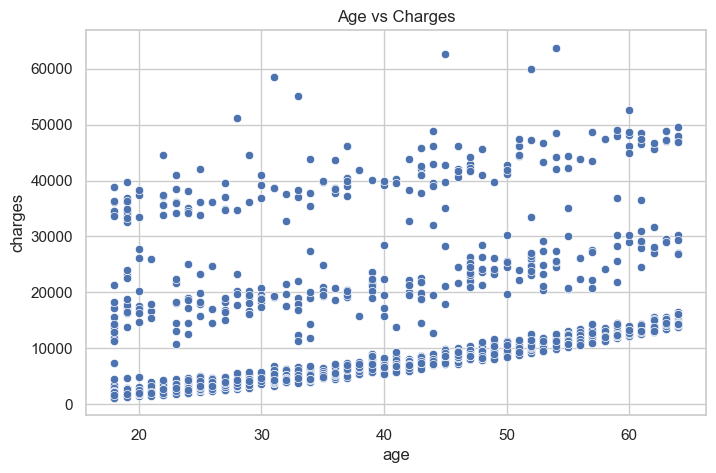

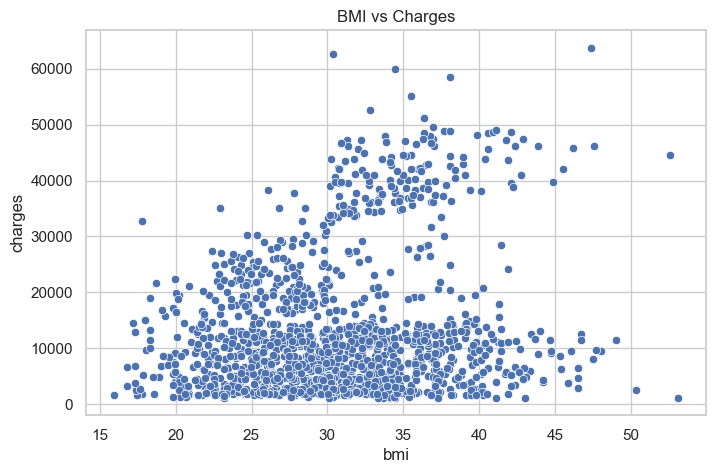

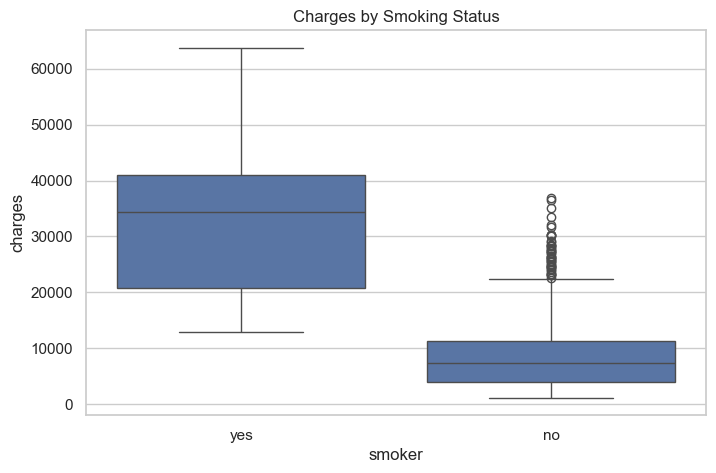

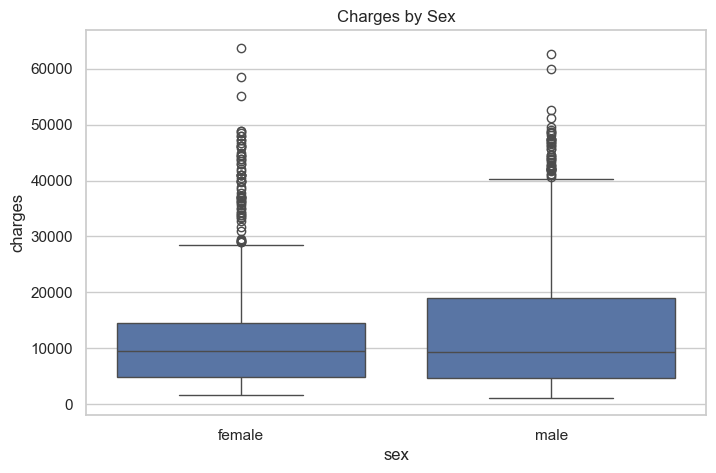

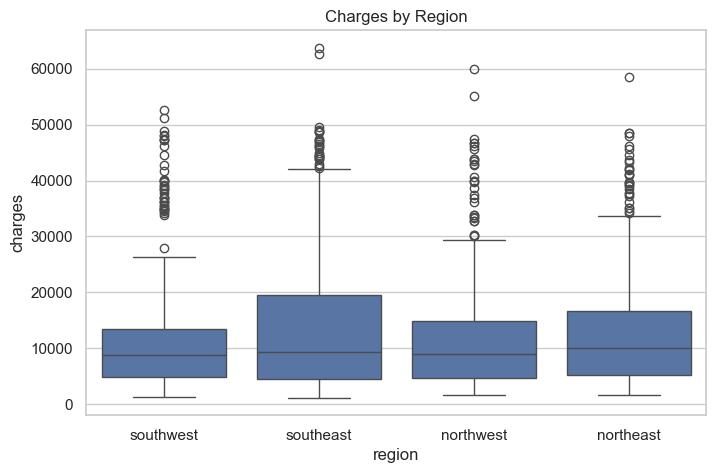

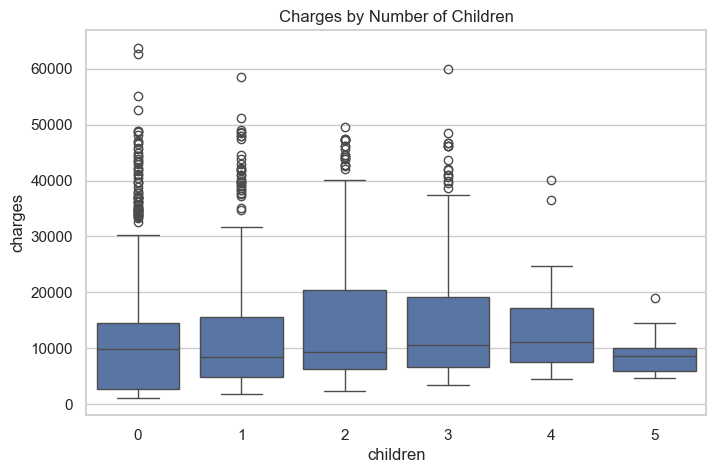

In [147]:
plt.figure()
sns.scatterplot(x=df['age'], y=df['charges'])
plt.title("Age vs Charges")
plt.show()

plt.figure()
sns.scatterplot(x=df['bmi'], y=df['charges'])
plt.title("BMI vs Charges")
plt.show()

plt.figure()
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title("Charges by Smoking Status")
plt.show()

plt.figure()
sns.boxplot(x=df['sex'], y=df['charges'])
plt.title("Charges by Sex")
plt.show()

plt.figure()
sns.boxplot(x=df['region'], y=df['charges'])
plt.title("Charges by Region")
plt.show()

plt.figure()
sns.boxplot(x=df['children'], y=df['charges'])
plt.title("Charges by Number of Children")
plt.show()

The plots in this section make it easier to see how medical charges change across the different variables in the dataset. **Age** shows a clear upward pattern, which suggests that charges generally increase as people get older. **BMI** also seems to be related to charges, but the pattern is weaker and more spread out. The biggest difference appears in **smoking status**, where smokers have much higher charges than non-smokers. This suggests that smoking may be one of the most important variables in the model. The other variables show weaker patterns.

#### Create a report-ready boxplot for smoking status and charges

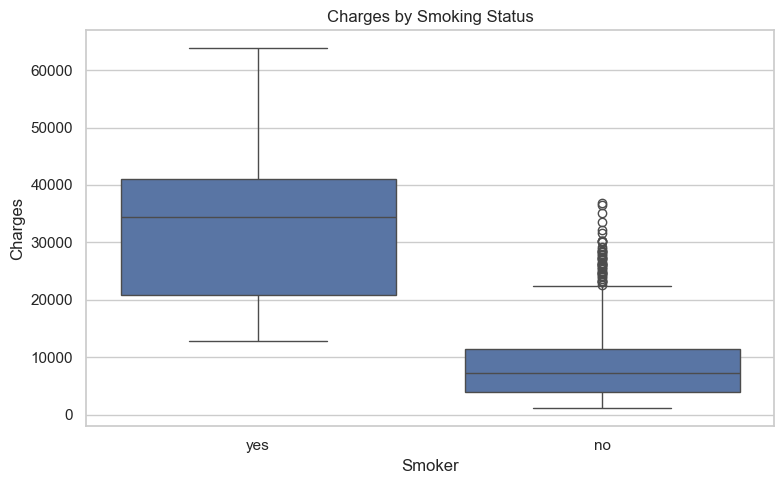

In [151]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['smoker'], y=df['charges'])
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.tight_layout()
plt.savefig("charges_by_smoker.png", bbox_inches="tight")
plt.show()

For the report, I am extracting the boxplot for **smoking status** because it shows one of the clearest patterns in the dataset.

#### Summarise the EDA findings

The EDA gave me a clearer picture of the dataset before moving on to modelling. The data was mostly clean, with no missing values and only one duplicate row, which was removed. The summary statistics and graphs also showed that the numeric variables are not distributed in the same way, especially **charges**, which is strongly right-skewed and contains some high-value outliers.

The visual analysis also showed which variables seem more closely linked to medical charges. **Smoking status** stood out the most, with smokers having much higher charges than non-smokers. **Age** showed a clear positive relationship with charges, and **BMI** also showed some relationship, although it was less consistent. Variables such as **sex**, **region**, and **children** appeared to have weaker patterns. Based on these findings, the dataset looks suitable for Linear Regression, and the next step is to prepare the features for model training.

### (b) Feature selection

In this section, I prepare the variables that will be used to train the Linear Regression model. I start with the variables given in the brief, namely **age, sex, BMI, number of children, smoking status, and region**. Since Linear Regression works with numeric input, I will convert the categorical variables into numeric form before selecting the final feature set.

#### Define the target variable and input features

In [171]:
X = df.drop('charges', axis=1)
y = df['charges']

print("Input features:")
print(X.head())

print("\nTarget variable (charges):")
print(y.head())

Input features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target variable (charges):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


I first separated the target variable from the predictor variables. The target variable is **charges**, because this is what the model must predict.

#### Encode the categorical variables

In [169]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


The dataset includes categorical variables such as **sex, smoker, and region**. These cannot be used directly in a Linear Regression model, so I converted them into numeric columns. The categorical variables were converted into numeric columns successfully.

#### Review the final feature set

In [183]:
print("Final feature columns:")
print(X_encoded.columns)

Final feature columns:
Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


The final feature set now is in the correct format for Linear Regression.

#### Create a report-ready feature selection table

To make the feature selection results easier to present, I created a small summary table showing the final encoded feature set used for modelling.

In [204]:
feature_table = pd.DataFrame({
    'Feature type': [
        'Original numeric features',
        'Encoded categorical features',
        'Target variable'
    ],
    'Variables': [
        'Age, BMI, Children',
        'Sex_male, Smoker_yes, Region_northwest, Region_southeast, Region_southwest',
        'Charges'
    ]
})
feature_table.to_excel("feature_selection_table.xlsx", index=False)
feature_table

,Feature type,Variables
0,Original numeric features,"Age, BMI, Children"
1,Encoded categorical features,"Sex_male, Smoker_yes, Region_northwest, Region..."
2,Target variable,Charges


#### Do an additional check to see which features appear more useful

To support feature selection, I will do one more check to see which features appear to have stronger relationships with the target variable, **charges**.

In [192]:
feature_corr = X_encoded.copy()
feature_corr['charges'] = y

feature_corr.corr()['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

This result shows that **smoker_yes** has the strongest positive relationship with **charges** by a big margin, which supports the earlier EDA finding that smoking status is one of the most important variables in the dataset. **Age** and **BMI** also show positive relationships with charges, although they are much weaker than smoking status.

#### A report-ready feature correlation table

To support the feature selection discussion in the report, I created a smaller table showing how the encoded features relate to charges.

In [208]:
corr_table = feature_corr.corr()['charges'].sort_values(ascending=False).reset_index()
corr_table.columns = ['Feature', 'Correlation with charges']
corr_table = corr_table[corr_table['Feature'] != 'charges']
corr_table = corr_table.round(3)

corr_table.to_excel("feature_correlation_table.xlsx", index=False)
corr_table

,Feature,Correlation with charges
1,smoker_yes,0.787
2,age,0.298
3,bmi,0.198
4,region_southeast,0.074
5,children,0.067
6,sex_male,0.058
7,region_northwest,-0.039
8,region_southwest,-0.044


#### Final feature selection decision

Based on the EDA findings and the additional feature check, I will keep all the variables from the brief in the first model. **Smoking status** appears to be the strongest predictor, while **age** and **BMI** also show useful relationships with charges.

### (c) Train model

In this section, I train the Linear Regression model using the prepared feature set. I first split the data into training and testing sets. After that, I fit the model to the training data and then use it to make predictions on the test data.

#### Split the data into training and testing sets

In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

train_test_table = pd.DataFrame({
    'Dataset portion': ['Training set', 'Testing set'],
    'Number of rows': [X_train.shape[0], X_test.shape[0]]
})

train_test_table.to_excel("train_test_split_table.xlsx", index=False)
train_test_table

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


,Dataset portion,Number of rows
0,Training set,1069
1,Testing set,268


The data was split successfully into training and testing sets. The summary table was also exported to Excel so that the train-test split can be presented more clearly in the report.

#### Train the Linear Regression model

In [223]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

The model was created using `LinearRegression()` and then trained with `.fit(X_train, y_train)`. At this stage, the model uses the training data to learn how the feature variables relate to the target variable, **charges**.

#### Make predictions on the test set

In [229]:
y_pred = lr_model.predict(X_test)

print("First 10 predicted values:")
print(y_pred[:10])

First 10 predicted values:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706 13149.72235307 30446.76067941  1453.28881259
 10633.01840233 11318.94379361]


The model has now generated predicted charge values for the test set. These predictions are stored in `y_pred`.

#### Compare a few actual and predicted values

I compare some of the predicted values to the actual values from the test set. This gives an idea of how close the model’s predictions are before calculating the formal evaluation metrics.

In [235]:
comparison_df = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

comparison_df = comparison_df.round(2)
comparison_df.head(10).to_excel("actual_vs_predicted_table.xlsx", index=False)
comparison_df.head(10)

,Actual Charges,Predicted Charges
0,8688.86,8143.69
1,5708.87,5737.12
2,11436.74,14369.31
3,38746.36,31745.51
4,4463.21,8962.39
5,9304.70,13149.72
6,38511.63,30446.76
7,2150.47,1453.29
8,7345.73,10633.02
9,10264.44,11318.94


This table compares the actual charges to the predicted charges for the first 10 cases in the test set. The predicted values are not exactly the same as the real values but many of them are reasonably close. In some cases, the model underestimates the charges, while in others it overestimates them. This gives a sign that the model is picking up the general pattern in the data.

## 4. Evaluate your model

### 4(a) Interpret and evaluate model

#### Calculate the model evaluation metrics and create a report-ready table

To evaluate the Linear Regression model properly, I calculate four standard regression metrics: **MAE, MSE, RMSE, and R²**. These measures help show how close the predictions are to the real values and how well the model fits the data overall. I also create a small table from the results so that they can be presented more clearly in the report.

In [244]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

evaluation_table = pd.DataFrame({
    'Metric': [
        'Mean Absolute Error (MAE)',
        'Mean Squared Error (MSE)',
        'Root Mean Squared Error (RMSE)',
        'R² Score'
    ],
    'Value': [mae, mse, rmse, r2]
})

evaluation_table = evaluation_table.round(2)
evaluation_table.to_excel("model_evaluation_table.xlsx", index=False)
evaluation_table

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 4177.045561036318
Mean Squared Error (MSE): 35478020.67523559
Root Mean Squared Error (RMSE): 5956.342894363587
R² Score: 0.8069287081198012


,Metric,Value
0,Mean Absolute Error (MAE),4177.05
1,Mean Squared Error (MSE),35478020.68
2,Root Mean Squared Error (RMSE),5956.34
3,R² Score,0.81


#### Interpret the evaluation metrics

The model evaluation results show that the Linear Regression model performed fairly well on the test data.

- **Mean Absolute Error (MAE): 4177.05**  
  This means that, on average, the model’s predictions were off by about **R4,177**.

- **Mean Squared Error (MSE): 35478020.68**  
  This measures the average prediction error after the differences have been squared. Bigger mistakes affect this number more strongly.

- **Root Mean Squared Error (RMSE): 5956.34**  
  This shows that the model’s error was about **R5,956** when bigger mistakes are given more weight. Since this is higher than the MAE, it suggests that some predictions were quite far from the real values.

- **R² Score: 0.81**  
  This means the model explained about **81%** of the changes in medical charges, which is a good result.

The model picked up a large part of the pattern in the data, but there is still some room for improvement, especially for higher charges.

#### Checking the residuals

A residual is the difference between the actual value and the predicted value. Looking at the residuals helps show whether the errors are spread out randomly or whether there may still be patterns the model is missing.

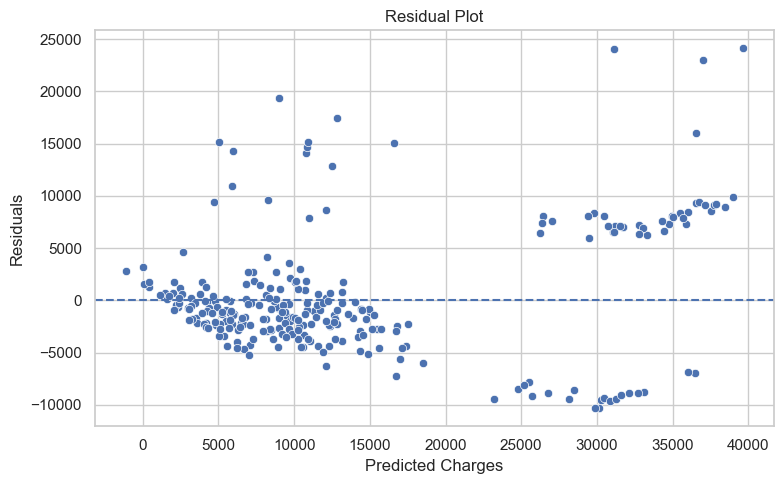

In [248]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("residual_plot.png", bbox_inches="tight")
plt.show()

The residual plot shows that the errors are not completely random around zero. The spread becomes wider at higher predicted charge values, which suggests that the model fits some parts of the data better than others. Which means the model sometimes underestimates and sometimes overestimates charges by quite a lot. This suggests that the model is not a perfect fit.

### 4(b) Retrain with different parameters

The first Linear Regression model performed fairly well, but the residual plot showed that some errors were still quite large, especially for higher charge values. To improve the model in a way that stays within the linear model family, I retrained it using **Ridge Regression**.

Ridge Regression is still a linear model, but it adds regularisation, which helps control coefficient size and reduce the risk of overfitting (Müller & Guido, 2016). I tested a few different **alpha** values to see which one gave the best result.

#### Train Ridge Regression models with different alpha values

In this step, I test several Ridge Regression models using different values of **alpha**. The alpha value controls the strength of the regularisation, so trying more than one value helps me see which version performs best on the test data.

In [284]:
from sklearn.linear_model import Ridge

alpha_values = [0.1, 1.0, 10.0, 100.0]

ridge_results = []

for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    ridge_pred = ridge_model.predict(X_test)
    
    ridge_mae = mean_absolute_error(y_test, ridge_pred)
    ridge_mse = mean_squared_error(y_test, ridge_pred)
    ridge_rmse = np.sqrt(ridge_mse)
    ridge_r2 = r2_score(y_test, ridge_pred)
    
    ridge_results.append({
        'Alpha': alpha,
        'MAE': ridge_mae,
        'MSE': ridge_mse,
        'RMSE': ridge_rmse,
        'R² Score': ridge_r2
    })

ridge_results_df = pd.DataFrame(ridge_results).round(2)
ridge_results_df.to_excel("ridge_alpha_results_table.xlsx", index=False)
ridge_results_df

,Alpha,MAE,MSE,RMSE,R² Score
0,0.1,4178.75,35495705.70,5957.83,0.81
1,1.0,4194.01,35656881.00,5971.34,0.81
2,10.0,4344.07,37440354.28,6118.85,0.80
3,100.0,5481.37,59465107.59,7711.36,0.68


The Ridge Regression results show that the best performance came from **alpha = 0.1**. As the alpha value increased, the model performance became weaker, with higher error values and a lower R² score. This suggests that stronger regularisation did not help this dataset and instead made the model fit the data less effectively. The table was also exported to Excel so that the results can be presented more clearly in the report.

#### Select the best Ridge model

I now choose the Ridge model that gives the strongest overall performance. In this case, I will focus mainly on **RMSE** and **R²**, because they help show both prediction error and overall fit.

In [265]:
best_ridge_row = ridge_results_df.sort_values(by='RMSE').iloc[0]
best_alpha = best_ridge_row['Alpha']

print("Best alpha:", best_alpha)
print(best_ridge_row)

Best alpha: 0.1
Alpha              0.10
MAE             4178.75
MSE         35495705.70
RMSE            5957.83
R² Score           0.81
Name: 0, dtype: float64


The best Ridge model was selected based on the lowest RMSE.

#### Train the final Ridge model

Using the best alpha value from the comparison, I now train the final Ridge Regression model and generate its predictions on the test set.

In [281]:
final_ridge_model = Ridge(alpha=best_alpha)
final_ridge_model.fit(X_train, y_train)
final_ridge_pred = final_ridge_model.predict(X_test)

ridge_comparison_df = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': final_ridge_pred
})

ridge_comparison_df = ridge_comparison_df.round(2)
ridge_comparison_df.head(10).to_excel("ridge_actual_vs_predicted_table.xlsx", index=False)
ridge_comparison_df.head(10)

,Actual Charges,Predicted Charges
0,8688.86,8146.45
1,5708.87,5739.84
2,11436.74,14370.81
3,38746.36,31734.59
4,4463.21,8966.48
5,9304.70,13153.66
6,38511.63,30434.48
7,2150.47,1455.88
8,7345.73,10636.07
9,10264.44,11321.85


This table shows the actual and predicted charges for the first 10 cases in the test set using the final Ridge model. I exported it to Excel to make it easier to compare with the earlier Linear Regression results.

#### Compare the original and retrained models

To see whether retraining improved the model, I compare the results of the original Linear Regression model to the final Ridge Regression model.

In [275]:
comparison_models = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE': [mae, mean_absolute_error(y_test, final_ridge_pred)],
    'MSE': [mse, mean_squared_error(y_test, final_ridge_pred)],
    'RMSE': [rmse, np.sqrt(mean_squared_error(y_test, final_ridge_pred))],
    'R² Score': [r2, r2_score(y_test, final_ridge_pred)]
}).round(2)

comparison_models.to_excel("model_comparison_table.xlsx", index=False)
comparison_models

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,4177.05,35478020.68,5956.34,0.81
1,Ridge Regression,4178.75,35495705.70,5957.83,0.81


When the best Ridge model was compared to the original Linear Regression model, the results showed no real improvement. The Linear Regression model had slightly lower error values and the same **R² score** of **0.81**. This means the original model performed marginally better overall, so it was kept as the final model.

## ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
##                               END